In [1]:
# %%
import json
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

# 所有日志都在这个目录下
BASE = Path(".") / "logs"
print("Log dir:", BASE.resolve())


Log dir: /home/lina/OWG-main/logs


In [2]:
# %%
def load_jsonl(path: Path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

def parse_time(t: str):
    # 日志里的时间格式是 "2025-11-22 11:16:10"
    return datetime.strptime(t, "%Y-%m-%d %H:%M:%S")


In [3]:
# %%
nl_path = BASE / "ui_nl_exec.jsonl"
grasp_path = BASE / "ui_grasp_exec.jsonl"
joint_path = BASE / "ui_joint_episodes.csv"

print("nl_path exists:", nl_path.exists())
print("grasp_path exists:", grasp_path.exists())

nl_rows = load_jsonl(nl_path)
grasp_rows = load_jsonl(grasp_path)

for r in nl_rows:
    r["_dt"] = parse_time(r["time"])
for r in grasp_rows:
    r["_dt"] = parse_time(r["time"])

nl_rows.sort(key=lambda r: r["_dt"])
grasp_rows.sort(key=lambda r: r["_dt"])

joint_rows = []
used_grasp_idx = set()

for i, nl in enumerate(nl_rows):
    t0 = nl["_dt"]
    t1 = nl_rows[i+1]["_dt"] if i + 1 < len(nl_rows) else None

    act = nl.get("action", {}) or {}
    a_type = act.get("action")
    a_input = act.get("input")
    a_target = act.get("target_id")
    grasps_idx = act.get("grasps", [])

    # 找在 [t0, t1) 区间内、还没匹配过的 grasp 日志
    candidates = []
    for j, g in enumerate(grasp_rows):
        if j in used_grasp_idx:
            continue
        tg = g["_dt"]
        if tg < t0:
            continue
        if t1 is not None and tg >= t1:
            continue
        candidates.append((j, g))

    if candidates:
        # 目前简化：假设每条 NL 最多关心一条 grasp（通常你是一次指令触发一次执行）
        j, g = sorted(candidates, key=lambda x: x[1]["_dt"])[0]
        used_grasp_idx.add(j)

        row = {
            "time_nl": nl["time"],
            "query": nl.get("query", ""),
            "hl_action": a_type,
            "input_id": a_input,
            "target_id": a_target,
            "grasps_idx": ";".join(str(x) for x in grasps_idx),
            "success_nl": bool(nl.get("success", False)),
            "time_grasp": g["time"],
            "mode": g.get("mode"),
            "obj_id": g.get("obj_id"),
            "obj_height": g.get("obj_height"),
            "x": g.get("x"),
            "y": g.get("y"),
            "z": g.get("z"),
            "yaw": g.get("yaw"),
            "opening_len": g.get("opening_len"),
            "success_grasp": bool(g.get("success_grasp", False)),
            "success_target": bool(g.get("success_target", False)),
        }
    else:
        # 没有配到 grasp 的指令
        row = {
            "time_nl": nl["time"],
            "query": nl.get("query", ""),
            "hl_action": a_type,
            "input_id": a_input,
            "target_id": a_target,
            "grasps_idx": ";".join(str(x) for x in grasps_idx),
            "success_nl": bool(nl.get("success", False)),
            "time_grasp": "",
            "mode": "",
            "obj_id": "",
            "obj_height": "",
            "x": "",
            "y": "",
            "z": "",
            "yaw": "",
            "opening_len": "",
            "success_grasp": False,
            "success_target": False,
        }

    joint_rows.append(row)

df_joint = pd.DataFrame(joint_rows)
df_joint.to_csv(joint_path, index=False)
print("Wrote joint episodes ->", joint_path)
df_joint


nl_path exists: True
grasp_path exists: True
Wrote joint episodes -> logs/ui_joint_episodes.csv


,time_nl,query,hl_action,input_id,target_id,grasps_idx,success_nl,time_grasp,mode,obj_id,obj_height,x,y,z,yaw,opening_len,success_grasp,success_target
0,2025-11-22 11:16:10,tomato soup,pick,9.0,9.0,0;1;2;3,False,2025-11-22 11:16:10,tray,9,None,None,None,None,None,None,False,False
1,2025-11-22 11:16:27,tomato soup,remove,10.0,9.0,0;1;2;3,True,,,,,,,,,,False,False
2,2025-11-22 11:16:36,tomato soup,pick,9.0,9.0,0,True,2025-11-22 11:16:36,tray,9,0.001734,0.434477,-0.68426,0.786734,-1.457436,0.031264,True,True
3,2025-11-22 11:18:11,chips,pick,16.0,16.0,0;1;2;3,True,2025-11-22 11:18:11,tray,16,0.069148,-0.052888,-0.749242,0.854148,-1.515838,0.029575,True,True
4,2025-11-22 11:18:29,tennis,pick,6.0,6.0,0;1;2;3,True,2025-11-22 11:18:29,tray,6,0.056025,-0.186462,-0.597617,0.841025,-0.500452,0.038045,True,True
5,2025-11-22 11:19:12,sauce\,remove,15.0,10.0,0;1;2;3,False,,,,,,,,,,False,False
6,2025-11-22 11:19:18,sauce\,fail,NaN,NaN,,False,,,,,,,,,,False,False
7,2025-11-22 11:19:31,sauce\,pick,10.0,10.0,0;1;2;3,True,2025-11-22 11:19:31,tray,10,0.03718,0.22148,-0.742022,0.82218,-0.461561,0.048281,True,True


In [4]:
# %%
df = pd.read_csv(BASE / "ui_joint_episodes.csv")
print("总行数:", len(df))
display(df.head())


总行数: 8


,time_nl,query,hl_action,input_id,target_id,grasps_idx,success_nl,time_grasp,mode,obj_id,obj_height,x,y,z,yaw,opening_len,success_grasp,success_target
0,2025-11-22 11:16:10,tomato soup,pick,9.0,9.0,0;1;2;3,False,2025-11-22 11:16:10,tray,9.0,NaN,NaN,NaN,NaN,NaN,NaN,False,False
1,2025-11-22 11:16:27,tomato soup,remove,10.0,9.0,0;1;2;3,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2,2025-11-22 11:16:36,tomato soup,pick,9.0,9.0,0,True,2025-11-22 11:16:36,tray,9.0,0.001734,0.434477,-0.684260,0.786734,-1.457436,0.031264,True,True
3,2025-11-22 11:18:11,chips,pick,16.0,16.0,0;1;2;3,True,2025-11-22 11:18:11,tray,16.0,0.069148,-0.052888,-0.749242,0.854148,-1.515838,0.029575,True,True
4,2025-11-22 11:18:29,tennis,pick,6.0,6.0,0;1;2;3,True,2025-11-22 11:18:29,tray,6.0,0.056025,-0.186462,-0.597617,0.841025,-0.500452,0.038045,True,True


In [5]:
# %%
# 每个 query 有多少条，高层 success_nl 的成功率
g_nl = df.groupby("query").agg(
    n_rows=("query", "size"),
    nl_success_rate=("success_nl", "mean"),
)
print("=== 每个 query 的 NL 成功率 ===")
display(g_nl)

# 过滤出有 grasp 日志的行
mask_grasp = df["time_grasp"].notna() & (df["time_grasp"] != "")
df_grasp = df[mask_grasp].copy()
print("\n有抓取记录的行数:", len(df_grasp))

if not df_grasp.empty:
    g_grasp = df_grasp.groupby("query").agg(
        n_grasp_rows=("query", "size"),
        grasp_success_rate=("success_grasp", "mean"),
        target_success_rate=("success_target", "mean"),
    )
    print("\n=== 每个 query 的抓取/放置成功率 ===")
    display(g_grasp)
else:
    print("目前还没有任何抓取日志被对齐到 NL。")


=== 每个 query 的 NL 成功率 ===


,n_rows,nl_success_rate
query,,
chips,1,1.000000
sauce\,3,0.333333
tennis,1,1.000000
tomato soup,3,0.666667



有抓取记录的行数: 5

=== 每个 query 的抓取/放置成功率 ===


,n_grasp_rows,grasp_success_rate,target_success_rate
query,,,
chips,1,1.0,1.0
sauce\,1,1.0,1.0
tennis,1,1.0,1.0
tomato soup,2,0.5,0.5


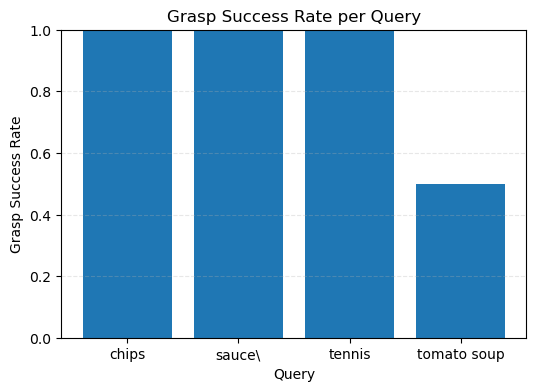

In [6]:
# %%
if not df_grasp.empty:
    g_grasp_plot = g_grasp.reset_index()

    plt.figure(figsize=(6, 4))
    plt.bar(g_grasp_plot["query"], g_grasp_plot["grasp_success_rate"])
    plt.title("Grasp Success Rate per Query")
    plt.xlabel("Query")
    plt.ylabel("Grasp Success Rate")
    plt.ylim(0, 1)
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.show()


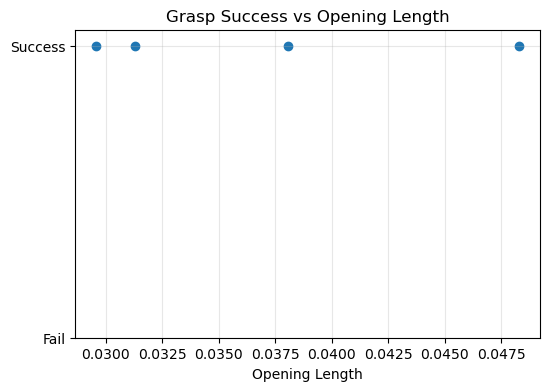

In [7]:
# %%
if not df_grasp.empty:
    # opening_len 可能是字符串，先转一下
    df_grasp_plot = df_grasp.copy()
    df_grasp_plot["opening_len"] = pd.to_numeric(df_grasp_plot["opening_len"], errors="coerce")

    plt.figure(figsize=(6, 4))
    # 用 0/1 映射
    y = df_grasp_plot["success_grasp"].astype(int)
    plt.scatter(df_grasp_plot["opening_len"], y)
    plt.title("Grasp Success vs Opening Length")
    plt.xlabel("Opening Length")
    plt.yticks([0, 1], ["Fail", "Success"])
    plt.grid(alpha=0.3)
    plt.show()


In [8]:
# %%
def agg_episode(g):
    return pd.Series({
        "success_nl"      : g["success_nl"].iloc[0],
        "any_grasp"       : g["time_grasp"].notna().any() and (g["time_grasp"] != "").any(),
        "any_grasp_succ"  : g["success_grasp"].fillna(False).any(),
        "all_grasp_succ"  : g["success_grasp"].fillna(True).all(),
        "any_target_succ" : g["success_target"].fillna(False).any(),
        "n_grasp_trials"  : (g["time_grasp"].notna() & (g["time_grasp"] != "")).sum(),
        "grasps_idx_union": ";".join(
            sorted(set(str(x) for x in g["grasps_idx"].dropna() if x != ""))
        ),
    })

group_cols = ["time_nl", "query", "hl_action", "input_id", "target_id"]
ep = df.groupby(group_cols, dropna=False).apply(agg_episode).reset_index()

ep_path = BASE / "ui_episodes_summary.csv"
ep.to_csv(ep_path, index=False)
print("Wrote episode summary ->", ep_path)
display(ep)


Wrote episode summary -> logs/ui_episodes_summary.csv


/tmp/ipykernel_11767/1944176522.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ep = df.groupby(group_cols, dropna=False).apply(agg_episode).reset_index()


,time_nl,query,hl_action,input_id,target_id,success_nl,any_grasp,any_grasp_succ,all_grasp_succ,any_target_succ,n_grasp_trials,grasps_idx_union
0,2025-11-22 11:16:10,tomato soup,pick,9.0,9.0,False,True,False,False,False,1,0;1;2;3
1,2025-11-22 11:16:27,tomato soup,remove,10.0,9.0,True,False,False,False,False,0,0;1;2;3
2,2025-11-22 11:16:36,tomato soup,pick,9.0,9.0,True,True,True,True,True,1,0
3,2025-11-22 11:18:11,chips,pick,16.0,16.0,True,True,True,True,True,1,0;1;2;3
4,2025-11-22 11:18:29,tennis,pick,6.0,6.0,True,True,True,True,True,1,0;1;2;3
5,2025-11-22 11:19:12,sauce\,remove,15.0,10.0,False,False,False,False,False,0,0;1;2;3
6,2025-11-22 11:19:18,sauce\,fail,NaN,NaN,False,False,False,False,False,0,
7,2025-11-22 11:19:31,sauce\,pick,10.0,10.0,True,True,True,True,True,1,0;1;2;3


In [9]:
# %%
print("总 episode 数:", len(ep))

ep_stats = {
    "nl_success_rate"     : ep["success_nl"].mean(),
    "any_grasp_succ_rate" : ep["any_grasp_succ"].mean(),
    "any_target_succ_rate": ep["any_target_succ"].mean(),
}
print("=== Episode-level 成功率 ===")
for k, v in ep_stats.items():
    print(f"{k}: {v:.3f}")


总 episode 数: 8
=== Episode-level 成功率 ===
nl_success_rate: 0.625
any_grasp_succ_rate: 0.500
any_target_succ_rate: 0.500


In [12]:
import pandas as pd

df_joint = pd.read_csv("logs/ui_joint_episodes.csv")               # NL + 抓取一体
df_grasp = pd.read_csv("logs/ui_grasp_exec.csv")                   # 纯抓取数据
df_cyl = pd.read_csv("grasp_6dof/out/cylinder_0p08_grasps_labeled.csv")  # cylinder 6DoF 数据


In [13]:
# 总体 NL 级成功率
df_joint["success_nl"].mean()

# 按 query 分组的成功率
df_joint.groupby("query")["success_nl"].mean()
df_joint.groupby("query")["success_nl"].count()  # 每个 query 的样本数


query
chips          1
sauce\         3
tennis         1
tomato soup    3
Name: success_nl, dtype: int64

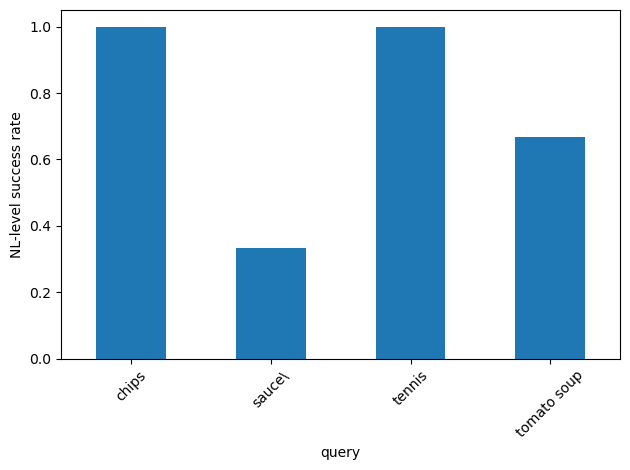

In [14]:
import matplotlib.pyplot as plt

stats = df_joint.groupby("query")["success_nl"].mean()
stats.plot(kind="bar")
plt.ylabel("NL-level success rate")
plt.xticks(rotation=45)
plt.tight_layout()


In [15]:
df_grasp["success_grasp"].mean()  # 低层抓取整体成功率

# 按 obj_id 看哪个物体更难抓
df_grasp.groupby("obj_id")["success_grasp"].mean()
df_grasp.groupby("obj_id")["success_grasp"].count()


obj_id
6     1
9     1
12    1
Name: success_grasp, dtype: int64

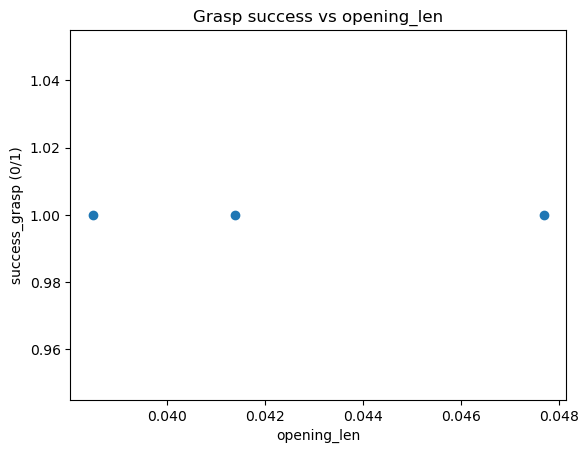

In [16]:
plt.scatter(df_grasp["opening_len"], df_grasp["success_grasp"])
plt.xlabel("opening_len")
plt.ylabel("success_grasp (0/1)")
plt.title("Grasp success vs opening_len")
plt.show()


In [17]:
df_cyl["success"].mean()           # cylinder grasps 成功率
df_cyl.head()


,x,y,z,roll,pitch,yaw,score,success
0,0.382441,-0.033615,0.054224,-3.077228,0.037145,1.570203,0.930392,1
1,0.380748,-0.037007,0.054528,-3.123575,0.013576,-3.141482,0.930222,1
2,0.374378,-0.033432,0.053814,3.132359,-0.085878,-0.009433,0.929278,0
3,0.378302,0.048991,0.054318,-3.092045,-0.008453,-1.568283,0.927770,0
4,0.373497,-0.006796,0.094165,-0.018027,0.019567,3.140274,0.927596,0


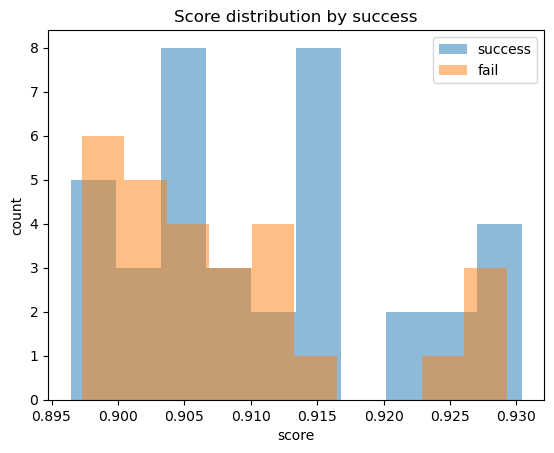

In [18]:
plt.hist(df_cyl[df_cyl["success"]==1]["score"], bins=10, alpha=0.5, label="success")
plt.hist(df_cyl[df_cyl["success"]==0]["score"], bins=10, alpha=0.5, label="fail")
plt.legend()
plt.xlabel("score")
plt.ylabel("count")
plt.title("Score distribution by success")
plt.show()


In [19]:
import pandas as pd

joint_path = "logs/ui_joint_episodes.csv"
cyl_path   = "grasp_6dof/out/cylinder_0p08_grasps_labeled.csv"
summary_path = "grasp_6dof/out/summary.csv"

df_joint = pd.read_csv(joint_path)
df_cyl   = pd.read_csv(cyl_path)
df_sum   = pd.read_csv(summary_path)

df_joint.head(), df_cyl.head(), df_sum.tail()


(               time_nl        query hl_action  input_id  target_id grasps_idx  \
 0  2025-11-22 11:16:10  tomato soup      pick       9.0        9.0    0;1;2;3   
 1  2025-11-22 11:16:27  tomato soup    remove      10.0        9.0    0;1;2;3   
 2  2025-11-22 11:16:36  tomato soup      pick       9.0        9.0          0   
 3  2025-11-22 11:18:11        chips      pick      16.0       16.0    0;1;2;3   
 4  2025-11-22 11:18:29       tennis      pick       6.0        6.0    0;1;2;3   
 
    success_nl           time_grasp  mode  obj_id  obj_height         x  \
 0       False  2025-11-22 11:16:10  tray     9.0         NaN       NaN   
 1        True                  NaN   NaN     NaN         NaN       NaN   
 2        True  2025-11-22 11:16:36  tray     9.0    0.001734  0.434477   
 3        True  2025-11-22 11:18:11  tray    16.0    0.069148 -0.052888   
 4        True  2025-11-22 11:18:29  tray     6.0    0.056025 -0.186462   
 
           y         z       yaw  opening_len  success

In [20]:
# 1）自然语言 -> 高层动作 是否成功
nl_success_rate = df_joint["success_nl"].mean()
print("自然语言层（LLM + Grounder + Planner）success_nl =", nl_success_rate)

# 2）有真实执行抓取的样本
has_exec = df_joint["time_grasp"].notna()
df_exec = df_joint[has_exec].copy()

print("有执行抓取的条数:", len(df_exec))

# 3）抓取动作是否成功（抓取 + 放置都成功才算 1）
exec_success_rate = (df_exec["success_grasp"] & df_exec["success_target"]).mean()
print("物理执行（grasp + place） success rate =", exec_success_rate)


自然语言层（LLM + Grounder + Planner）success_nl = 0.625
有执行抓取的条数: 5
物理执行（grasp + place） success rate = 0.8


In [21]:
df_joint[df_joint["success_nl"] == False][["time_nl", "query", "hl_action", "input_id", "target_id"]]


,time_nl,query,hl_action,input_id,target_id
0,2025-11-22 11:16:10,tomato soup,pick,9.0,9.0
5,2025-11-22 11:19:12,sauce\,remove,15.0,10.0
6,2025-11-22 11:19:18,sauce\,fail,NaN,NaN


In [22]:
print("Cylinder grasps total:", len(df_cyl))
print("Cylinder grasp success rate:", df_cyl["success"].mean())

# 看一下 score vs success 的大致关系
df_cyl.sort_values("score", ascending=False).head(10)


Cylinder grasps total: 64
Cylinder grasp success rate: 0.578125


,x,y,z,roll,pitch,yaw,score,success
0,0.382441,-0.033615,0.054224,-3.077228,0.037145,1.570203,0.930392,1
1,0.380748,-0.037007,0.054528,-3.123575,0.013576,-3.141482,0.930222,1
2,0.374378,-0.033432,0.053814,3.132359,-0.085878,-0.009433,0.929278,0
3,0.378302,0.048991,0.054318,-3.092045,-0.008453,-1.568283,0.927770,0
4,0.373497,-0.006796,0.094165,-0.018027,0.019567,3.140274,0.927596,0
5,0.382932,0.000106,0.054188,-2.993334,-0.034784,1.568119,0.927353,1
6,0.377802,0.025641,0.054236,3.119225,0.119150,-3.126683,0.927220,1
7,0.385850,-0.052337,0.094636,-0.145526,0.092531,-1.568915,0.925420,1
8,0.380748,-0.037007,0.054528,3.137221,-0.029636,-0.785317,0.924372,1
9,0.377148,-0.024805,0.054178,-3.128055,-0.094671,-0.009594,0.923965,0


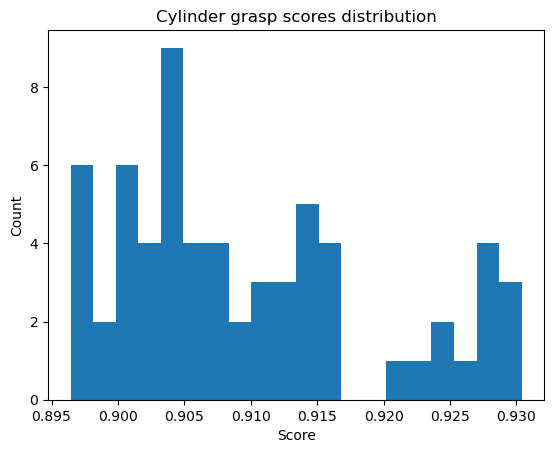

In [23]:
import matplotlib.pyplot as plt

plt.hist(df_cyl["score"], bins=20)
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Cylinder grasp scores distribution")
plt.show()


In [24]:
def format_action(row):
    a = row["hl_action"]
    inp = row["input_id"]
    tgt = row["target_id"]
    if pd.isna(a):
        return ""
    if a == "pick":
        return f"pick({int(inp)})"
    elif a == "remove":
        return f"remove({int(inp)}) -> pick({int(tgt)})"
    elif a == "fail":
        return "fail"
    else:
        return str(a)

df_joint["action_str"] = df_joint.apply(format_action, axis=1)

df_for_llm = df_joint[["time_nl","query","action_str","success_nl"]].copy()
df_for_llm.to_csv("logs/ui_nl_episodes_for_train.csv", index=False)
df_for_llm.head(10)


,time_nl,query,action_str,success_nl
0,2025-11-22 11:16:10,tomato soup,pick(9),False
1,2025-11-22 11:16:27,tomato soup,remove(10) -> pick(9),True
2,2025-11-22 11:16:36,tomato soup,pick(9),True
3,2025-11-22 11:18:11,chips,pick(16),True
4,2025-11-22 11:18:29,tennis,pick(6),True
5,2025-11-22 11:19:12,sauce\,remove(15) -> pick(10),False
6,2025-11-22 11:19:18,sauce\,fail,False
7,2025-11-22 11:19:31,sauce\,pick(10),True


## 1. System Overview（OWG-based Language-Conditioned Grasping）

We build on the OWG framework to realize language-conditioned grasping in a PyBullet simulation.

**Perception → Language Grounding → Planning → Grasp Execution**:

1. **Camera**  
   - A fixed RGB-D camera observes the tabletop scene and provides RGB image, depth map, and segmentation masks.

2. **Open-vocabulary Grounding (Grounding DINO / OWL-ViT)**  
   - Given a natural language query (e.g., *"tomato soup"*, *"tennis ball"*, *"chips"*), an open-vocabulary detector produces:
     - bounding boxes and masks for all candidate objects,
     - a set of matched object IDs for the query.

3. **LLM Planner**  
   - A large language model receives:
     - the query,
     - the detected object IDs and their spatial relations (e.g., which object is “on top of” which),
   - and outputs a **high-level action sequence**, e.g.:
     ```json
     [
       {"action": "remove", "input": 10},
       {"action": "pick", "input": 9}
     ]
     ```
   - This corresponds to removing blocking objects before grasping the target.

4. **GR-ConvNet Grasp Generator (4-DoF)**  
   - For each selected object, a GR-ConvNet-based grasp generator predicts a set of pixel-wise 4-DoF grasps:
     - grasp center (u, v),
     - in-plane rotation,
     - gripper width and grasp quality score.
   - Candidate grasps are converted from image space to robot base frame and attached to each object via:
     - `env.set_obj_grasps(obj_id, grasps, grasp_rects)`
     - `env.get_obj_grasps(obj_id)`.

5. **PyBullet Execution**  
   - The environment executes the chosen grasp using a Franka Panda arm in PyBullet:
     - move end-effector above the grasp pose,
     - approach along the local z-axis,
     - close the gripper and lift the object,
     - optionally place it in a tray or a “free space” region.
   - Execution success is determined by whether the object is stably grasped and reaches the target region.

This pipeline forms the **Stage 1 baseline** for our later extensions:
- Stage 2: 6-DoF geometric grasp generation and validation.
- Stage 3–4: language-conditioned grasp scoring with multi-modal features.
- Stage 5–6: closed-loop control and real-robot deployment.


## 2. Data Logging Schema

To analyze the behavior of the OWG-based system, we log three levels of data:

1. **Natural Language Execution Log** – `logs/ui_nl_exec.jsonl`  
   - One line per **language-command episode**.
   - Fields:
     - `time` : timestamp (`"%Y-%m-%d %H:%M:%S"`)
     - `query` : raw natural language query string (e.g., `"tomato soup"`, `"chips"`, `"tennis"`)
     - `action` : a dict containing the final high-level action selected by the planner, e.g.  
       - `action["action"]` : `"pick"`, `"remove"`, or `"fail"`
       - `action["input"]` : object id chosen by the planner (if applicable)
       - `action["target_id"]` : target object id
       - `action["grasps"]` : indices of candidate grasps used
     - `success` : whether this **episode** is considered successful from the high-level task perspective (e.g., target object eventually grasped and moved as intended).

2. **Grasp Execution Log** – `logs/ui_grasp_exec.jsonl`  
   - One line per **low-level grasp execution**.
   - Fields:
     - `time` : timestamp of grasp execution
     - `mode` : execution mode (e.g., `"tray"` for placing into the tray)
     - `obj_id` : object id being grasped
     - `x, y, z` : grasp position in the robot base frame
     - `yaw` : in-plane rotation of the gripper around the vertical axis
     - `opening_len` : gripper opening length during grasp
     - `obj_height` : estimated object height used for approach planning
     - `success_grasp` : whether the grasp itself succeeded (object lifted stably)
     - `success_target` : whether the object reached the desired target region

3. **Joint NL–Grasp Episodes** – `logs/ui_joint_episodes.csv`  
   - A post-processed table that aligns high-level NL episodes with their closest grasp execution (if any).
   - Key fields:
     - `time_nl` : timestamp of the NL episode
     - `query` : NL query string
     - `hl_action` : planner action type (`pick/remove/fail`)
     - `input_id` : planner input object id
     - `target_id` : target object id
     - `grasps_idx` : indices of candidate grasps used (e.g., `"0;1;2;3"`)
     - `success_nl` : high-level success flag (from `ui_nl_exec`)
     - `time_grasp` : timestamp of the matched grasp execution (if any)
     - `mode` : grasp execution mode
     - `obj_id` : object id grasped in the matched execution
     - `obj_height` : object height estimate
     - `x, y, z, yaw, opening_len` : executed grasp pose and gripper opening
     - `success_grasp` : low-level grasp success
     - `success_target` : target-reaching success

This logging schema allows us to compute:
- **NL-level success rates** for different query types, and  
- **grasp-level success rates** conditioned on language commands,
providing a bridge between language understanding and physical execution.


In [34]:
import pandas as pd
from pathlib import Path

base = Path("logs")

# 读取已经对齐好的 joint episodes（你刚才生成的 ui_joint_episodes.csv）
df = pd.read_csv(base / "ui_joint_episodes.csv")

# 1. 处理布尔列（有些可能是字符串/NaN）
def to_bool(col):
    return col.astype(str).map(lambda x: True if x == "True" or x == "1" else False)

df["success_nl"] = to_bool(df["success_nl"])

if "success_grasp" in df.columns:
    df["success_grasp"] = to_bool(df["success_grasp"])
if "success_target" in df.columns:
    df["success_target"] = to_bool(df["success_target"])

# 2. 定义：哪些 episode 有匹配到 grasp 执行
has_grasp = df["time_grasp"].notna()
df["has_grasp"] = has_grasp

# 3. 定义 grasp-level success：同时抓取成功 + 到达目标
df["success_grasp_exec"] = df["success_grasp"] & df["success_target"]

# 4. 按 query 分组统计
rows = []
for query, g in df.groupby("query"):
    # 忽略空 query（比如某些失败日志可能是空字符串）
    if isinstance(query, float) and pd.isna(query):
        continue

    n_episodes = len(g)
    nl_success_rate = g["success_nl"].mean()  # 高层任务成功率

    g_with = g[g["has_grasp"]]
    n_with_grasp = len(g_with)
    grasp_success_rate = g_with["success_grasp_exec"].mean() if n_with_grasp > 0 else float("nan")

    rows.append({
        "query": query,
        "n_episodes": n_episodes,
        "nl_success_rate": nl_success_rate,
        "n_with_grasp": n_with_grasp,
        "grasp_success_rate": grasp_success_rate,
    })

summary_df = pd.DataFrame(rows).sort_values("query").reset_index(drop=True)

# 5. 输出结果
summary_df


,query,n_episodes,nl_success_rate,n_with_grasp,grasp_success_rate
0,chips,1,1.000000,1,1.0
1,sauce\,3,0.333333,1,1.0
2,tennis,1,1.000000,1,1.0
3,tomato soup,3,0.666667,2,0.5


### 1.2 Quantitative statistics of Stage-1 OWG replication

We collected a small set of natural-language interaction episodes with the OWG UI.
For each distinct query string, we report:  
- **n_episodes**: number of NL interaction episodes,  
- **nl_success_rate**: fraction of episodes where the planner produced a valid high-level action,  
- **n_with_grasp**: number of episodes that led to a grasp execution in PyBullet,  
- **grasp_success_rate**: fraction of those executions that successfully placed the object in the tray.

The current statistics are summarised in Table X (chips / tennis reach 100% NL and grasp success; *tomato soup* shows 0.67 NL success and 0.5 grasp success, and *sauce\\* illustrates failure cases of the planner and grasping pipeline).


In [40]:
import pandas as pd

pairs = pd.read_csv("./logs/lggsn_pairs.csv")
pairs.head()
pairs['query'].value_counts()
pairs['label'].value_counts()


label
1    4
0    4
Name: count, dtype: int64

In [41]:
import pandas as pd
from pathlib import Path

ROOT = Path.home() / "OWG-main"   # 注意是现在的路径

# 假设你 notebook 里已经有 pairs 这个 DataFrame
# 如果是从别的地方读的，就先重新读：
# pairs = pd.read_csv("之前保存的 lggsn_pairs.csv 路径")

out_path = ROOT / "lggsn_pairs.csv"
pairs.to_csv(out_path, index=False)
print("Saved to:", out_path)


Saved to: /home/lina/OWG-main/lggsn_pairs.csv
